# Simple Policy Gradient

In [1]:
from torch import nn


def build_mlp(sizes: list[int]):
    layers = []
    for i in range(len(sizes)-1):
        layers.append(nn.Linear(sizes[i], sizes[i+1]))
        if i != len(sizes) - 2: layers.append(nn.ReLU())
    return nn.Sequential(*layers)

obs, actions: 4, 2
Sequential(
  (0): Linear(in_features=4, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=2, bias=True)
)
0 21.224510192871094 23.75 44
1 22.029918670654297 25.024390243902438 41
2 24.85672378540039 27.526315789473685 38
3 34.1504020690918 37.96296296296296 27
4 24.471834182739258 28.63888888888889 36
5 28.311771392822266 34.1875 32
6 26.218658447265625 31.333333333333332 33
7 28.574804306030273 36.642857142857146 28
8 29.125049591064453 34.064516129032256 31
9 36.20319747924805 41.64 25
10 34.481170654296875 41.12 25
11 31.2611141204834 41.24 25
12 31.346282958984375 42.666666666666664 24
13 31.662866592407227 41.8 25
14 40.904884338378906 52.42857142857143 21
15 46.76456069946289 50.69565217391305 23
16 32.91989517211914 39.88461538461539 26
17 37.0150032043457 48.59090909090909 22
18 35.32337951660156 46.47826086956522 23
19 50.55888748168945 55.31578947368421 19
20 41.63943099975586 58.333333333333336 18
21 36.120567321777344 5

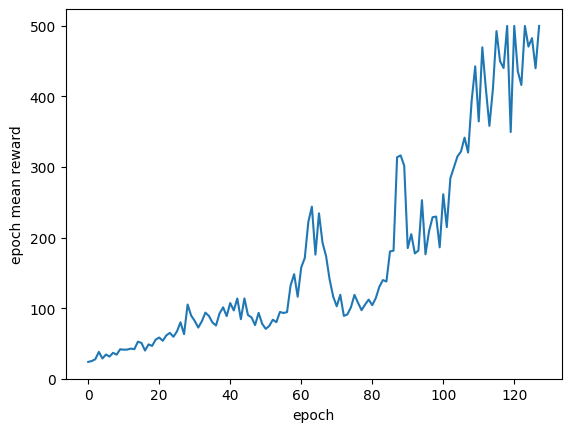

In [2]:
import torch
from torch.optim import Adam
from torch.distributions import Categorical
import gymnasium as gym
import matplotlib.pyplot as plt


N_EPOCHS = 128
BATCH_SIZE = 1024
DEVICE = "cpu"

env = gym.make("CartPole-v1")
n_obs = env.observation_space.shape[0]
n_actions = int(env.action_space.n)
print(f"obs, actions: {n_obs}, {n_actions}")

policy = build_mlp([n_obs, 32, n_actions])
policy.to(DEVICE)
print(policy)

optim = Adam(policy.parameters(), lr=1e-2)

epoch_mean_rewards = []
for epoch in range(N_EPOCHS):
    # Sample episode. Collect action log probs and rewards.
    log_probs = []
    rewards = []
    total_rewards = []

    while len(log_probs) < BATCH_SIZE:
        episode_rewards = []

        obs, _ = env.reset()
        while True:
            obs = torch.tensor(obs, dtype=torch.float32, device=DEVICE)
            logits = policy(obs.unsqueeze(0))[0]

            action_dist = Categorical(logits=logits)
            action = action_dist.sample()
            log_probs.append(action_dist.log_prob(action))

            obs, reward, terminated, truncated, _ = env.step(action.item())
            episode_rewards.append(reward)

            if terminated or truncated:
                break

        total_reward = sum(episode_rewards)
        rewards += len(episode_rewards) * [total_reward]
        total_rewards.append(total_reward)

    log_probs = torch.stack(log_probs)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)

    # Optimize policy.
    loss = -(log_probs * rewards).mean()

    optim.zero_grad()
    loss.backward()
    optim.step()

    # Log.
    epoch_mean_reward = sum(total_rewards) / len(total_rewards)
    epoch_mean_rewards.append(epoch_mean_reward)
    print(epoch, loss.item(), epoch_mean_reward, len(total_rewards))

plt.plot(epoch_mean_rewards)
plt.xlabel("epoch")
plt.ylabel("epoch mean reward")
plt.show()

# Rewards-to-go

obs, actions: 4, 2
Sequential(
  (0): Linear(in_features=4, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=2, bias=True)
)
0 11.928183555603027 23.08695652173913 46
1 10.016695022583008 23.976744186046513 43
2 13.223745346069336 25.78048780487805 41
3 14.048836708068848 32.375 32
4 11.620844841003418 26.28205128205128 39
5 13.95865249633789 30.5 34
6 14.242486000061035 32.0625 32
7 14.611418724060059 36.67857142857143 28
8 16.907920837402344 41.48 25
9 19.053264617919922 41.84615384615385 26
10 18.956573486328125 46.72727272727273 22
11 19.464920043945312 47.869565217391305 23
12 18.93701934814453 49.142857142857146 21
13 24.225204467773438 57.26315789473684 19
14 16.673526763916016 48.72727272727273 22
15 23.204492568969727 60.0 18
16 17.617441177368164 50.04761904761905 21
17 26.975454330444336 64.9375 16
18 19.864255905151367 58.05555555555556 18
19 25.822561264038086 66.375 16
20 20.28837776184082 57.666666666666664 18
21 20.615880966186523 64.

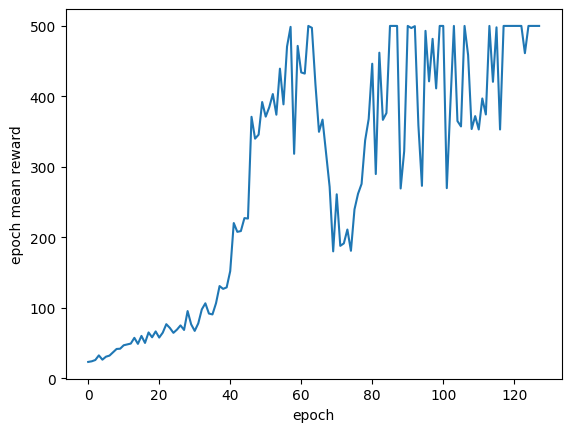

In [3]:
N_EPOCHS = 128
BATCH_SIZE = 1024
DEVICE = "cpu"

env = gym.make("CartPole-v1")
n_obs = env.observation_space.shape[0]
n_actions = int(env.action_space.n)
print(f"obs, actions: {n_obs}, {n_actions}")

policy = build_mlp([n_obs, 32, n_actions])
policy.to(DEVICE)
print(policy)

optim = Adam(policy.parameters(), lr=1e-2)

epoch_mean_rewards = []
for epoch in range(N_EPOCHS):
    # Sample episode. Collect action log probs and rewards.
    log_probs = []
    rewards = []
    total_rewards = []

    while len(log_probs) < BATCH_SIZE:
        episode_rewards = []

        obs, _ = env.reset()
        while True:
            obs = torch.tensor(obs, dtype=torch.float32, device=DEVICE)
            logits = policy(obs.unsqueeze(0))[0]

            action_dist = Categorical(logits=logits)
            action = action_dist.sample()
            log_probs.append(action_dist.log_prob(action))

            obs, reward, terminated, truncated, _ = env.step(action.item())
            episode_rewards.append(reward)

            if terminated or truncated:
                break

        total_rewards.append(sum(episode_rewards))

        # Rewards to go.
        for i in range(len(episode_rewards) - 2, -1, -1):
            episode_rewards[i] += episode_rewards[i+1]
        rewards += episode_rewards

    log_probs = torch.stack(log_probs)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=DEVICE)

    # Optimize policy.
    loss = -(log_probs * rewards).mean()

    optim.zero_grad()
    loss.backward()
    optim.step()

    # Log.
    epoch_mean_reward = sum(total_rewards) / len(total_rewards)
    epoch_mean_rewards.append(epoch_mean_reward)
    print(epoch, loss.item(), epoch_mean_reward, len(total_rewards))

plt.plot(epoch_mean_rewards)
plt.xlabel("epoch")
plt.ylabel("epoch mean reward")
plt.show()